# Разведочный анализ данных

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:.4f}".format)

TARGET = "Y house price of unit area"


def find_project_dir() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd.parent, cwd / "1_linear_regression_house_prices"]
    candidates.extend(cwd.parents)
    candidates.extend(parent / "1_linear_regression_house_prices" for parent in cwd.parents)

    seen = set()
    for candidate in candidates:
        try:
            path = candidate.resolve()
        except OSError:
            continue
        if path in seen:
            continue
        seen.add(path)
        if (path / "data" / "prices_train.csv").exists() and (path / "data" / "prices_test.csv").exists():
            return path
    raise FileNotFoundError("Не найдена папка проекта с data/prices_train.csv")


PROJECT_DIR = find_project_dir()
DATA_DIR = PROJECT_DIR / "data"
TRAIN_PATH = DATA_DIR / "prices_train.csv"
TEST_PATH = DATA_DIR / "prices_test.csv"

train = pd.read_csv(TRAIN_PATH, index_col=0)
test = pd.read_csv(TEST_PATH, index_col=0)
feature_cols = [column for column in train.columns if column != TARGET]

PROJECT_DIR

## 1. Структура данных


In [2]:
overview = pd.DataFrame(
    {
        "rows": [len(train), len(test)],
        "columns": [train.shape[1], test.shape[1]],
    },
    index=["train", "test"],
)

column_info = pd.DataFrame({"column": train.columns})
column_info = column_info.assign(
    train_dtype=column_info["column"].map(lambda column: str(train[column].dtype) if column in train else None),
    test_dtype=column_info["column"].map(lambda column: str(test[column].dtype) if column in test else None),
)
column_info["test_dtype"] = column_info["test_dtype"].fillna("NaN")

train_preview = train[feature_cols + [TARGET]].head().rename_axis("index")
test_preview = test[feature_cols].head().rename_axis("index")

display(overview)
display(column_info)
display(train_preview)
display(test_preview)

,rows,columns
train,331,7
test,83,6


,column,train_dtype,test_dtype
0,X1 transaction date,float64,float64
1,X2 house age,float64,float64
2,X3 distance to the nearest MRT station,float64,float64
3,X4 number of convenience stores,float64,float64
4,X5 latitude,float64,float64
5,X6 longitude,float64,float64
6,Y house price of unit area,float64,NaN


,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
index,,,,,,,
0,2013.0830,34.0000,157.6052,7.0000,24.9663,121.5420,39.1000
1,2013.5000,13.3000,561.9845,5.0000,24.9875,121.5439,54.8000
2,2012.9170,13.7000,1236.5640,1.0000,24.9769,121.5539,30.6000
3,2013.5000,8.5000,104.8101,5.0000,24.9667,121.5407,55.5000
4,2013.5000,13.2000,1164.8380,NaN,24.9916,121.5341,34.3000


,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude
index,,,,,,
0,2012.8330,3.4000,NaN,NaN,24.9574,121.5371
1,2013.0830,34.8000,405.2134,1.0000,24.9735,121.5337
2,2013.5000,4.1000,2147.3760,3.0000,24.9630,121.5128
3,2012.9170,18.9000,1009.2350,0.0000,24.9636,121.5495
4,2013.4170,3.9000,2147.3760,3.0000,24.9630,121.5128


## 2. Пропуски

In [3]:
missing = pd.DataFrame(index=train.columns.union(test.columns))
missing["train_missing"] = train.isna().sum().reindex(missing.index)
missing["train_missing_pct"] = missing["train_missing"] / len(train) * 100
missing["test_missing"] = test.isna().sum().reindex(missing.index)
missing["test_missing_pct"] = missing["test_missing"] / len(test) * 100
missing = missing.fillna(0).sort_values(["train_missing", "test_missing"], ascending=False)

duplicates = pd.DataFrame(
    {
        "duplicated_rows": [train.duplicated().sum(), test.duplicated().sum()],
    },
    index=["train", "test"],
)

display(missing)
display(duplicates)

,train_missing,train_missing_pct,test_missing,test_missing_pct
X4 number of convenience stores,14,4.2296,7.0000,8.4337
X2 house age,8,2.4169,0.0000,0.0000
X3 distance to the nearest MRT station,7,2.1148,5.0000,6.0241
X1 transaction date,0,0.0000,0.0000,0.0000
X5 latitude,0,0.0000,0.0000,0.0000
X6 longitude,0,0.0000,0.0000,0.0000
Y house price of unit area,0,0.0000,0.0000,0.0000


,duplicated_rows
train,0
test,1


## 3. Описательные статистики

In [4]:
display(train.describe().T)
display(test.describe().T)

,count,mean,std,min,25%,50%,75%,max
X1 transaction date,331.0000,2013.1410,0.2818,2012.6670,2012.9170,2013.0830,2013.4170,2013.5830
X2 house age,323.0000,17.9375,11.3961,0.0000,9.8000,15.9000,29.2000,43.8000
X3 distance to the nearest MRT station,324.0000,1102.3613,1307.9751,23.3828,289.3248,492.2313,1414.8370,6488.0210
X4 number of convenience stores,317.0000,4.0726,2.9389,0.0000,1.0000,4.0000,6.0000,10.0000
X5 latitude,331.0000,24.9691,0.0129,24.9321,24.9630,24.9721,24.9784,25.0146
X6 longitude,331.0000,121.5336,0.0154,121.4735,121.5297,121.5391,121.5434,121.5663
Y house price of unit area,331.0000,38.2940,13.7662,7.6000,28.5500,38.8000,46.6000,117.5000


,count,mean,std,min,25%,50%,75%,max
X1 transaction date,83.0000,2013.1808,0.2821,2012.6670,2012.9170,2013.2500,2013.4170,2013.5830
X2 house age,83.0000,15.7060,10.6543,0.0000,7.1500,16.8000,19.2000,41.3000
X3 distance to the nearest MRT station,78.0000,1070.0476,1130.2087,23.3828,289.3248,559.7313,1716.0528,6306.1530
X4 number of convenience stores,76.0000,3.8421,2.9532,0.0000,1.0000,3.0000,6.0000,10.0000
X5 latitude,83.0000,24.9686,0.0103,24.9415,24.9632,24.9687,24.9748,24.9901
X6 longitude,83.0000,121.5324,0.0150,121.4752,121.5167,121.5374,121.5432,121.5596


## 4. Выбросы

Критерий: `x < Q1 - 1.5 * IQR` или `x > Q3 + 1.5 * IQR`

,column,outliers,outliers_pct,lower_bound,upper_bound,min,max
2,X3 distance to the nearest MRT station,34,10.2719,-1398.9435,3103.1053,23.3828,6488.0210
5,X6 longitude,33,9.9698,121.5091,121.5640,121.4735,121.5663
4,X5 latitude,7,2.1148,24.9398,25.0016,24.9321,25.0146
6,Y house price of unit area,2,0.6042,1.4750,73.6750,7.6000,117.5000
0,X1 transaction date,0,0.0000,2012.1670,2014.1670,2012.6670,2013.5830
1,X2 house age,0,0.0000,-19.3000,58.3000,0.0000,43.8000
3,X4 number of convenience stores,0,0.0000,-6.5000,13.5000,0.0000,10.0000


,column,outliers,outliers_pct,lower_bound,upper_bound,min,max
1,X2 house age,4,4.8193,-10.9250,37.2750,0.0000,41.3000
2,X3 distance to the nearest MRT station,4,4.8193,-1850.7671,3856.1447,23.3828,6306.1530
4,X5 latitude,3,3.6145,24.9459,24.9922,24.9415,24.9901
5,X6 longitude,1,1.2048,121.4769,121.5830,121.4752,121.5596
0,X1 transaction date,0,0.0000,2012.1670,2014.1670,2012.6670,2013.5830
3,X4 number of convenience stores,0,0.0000,-6.5000,13.5000,0.0000,10.0000


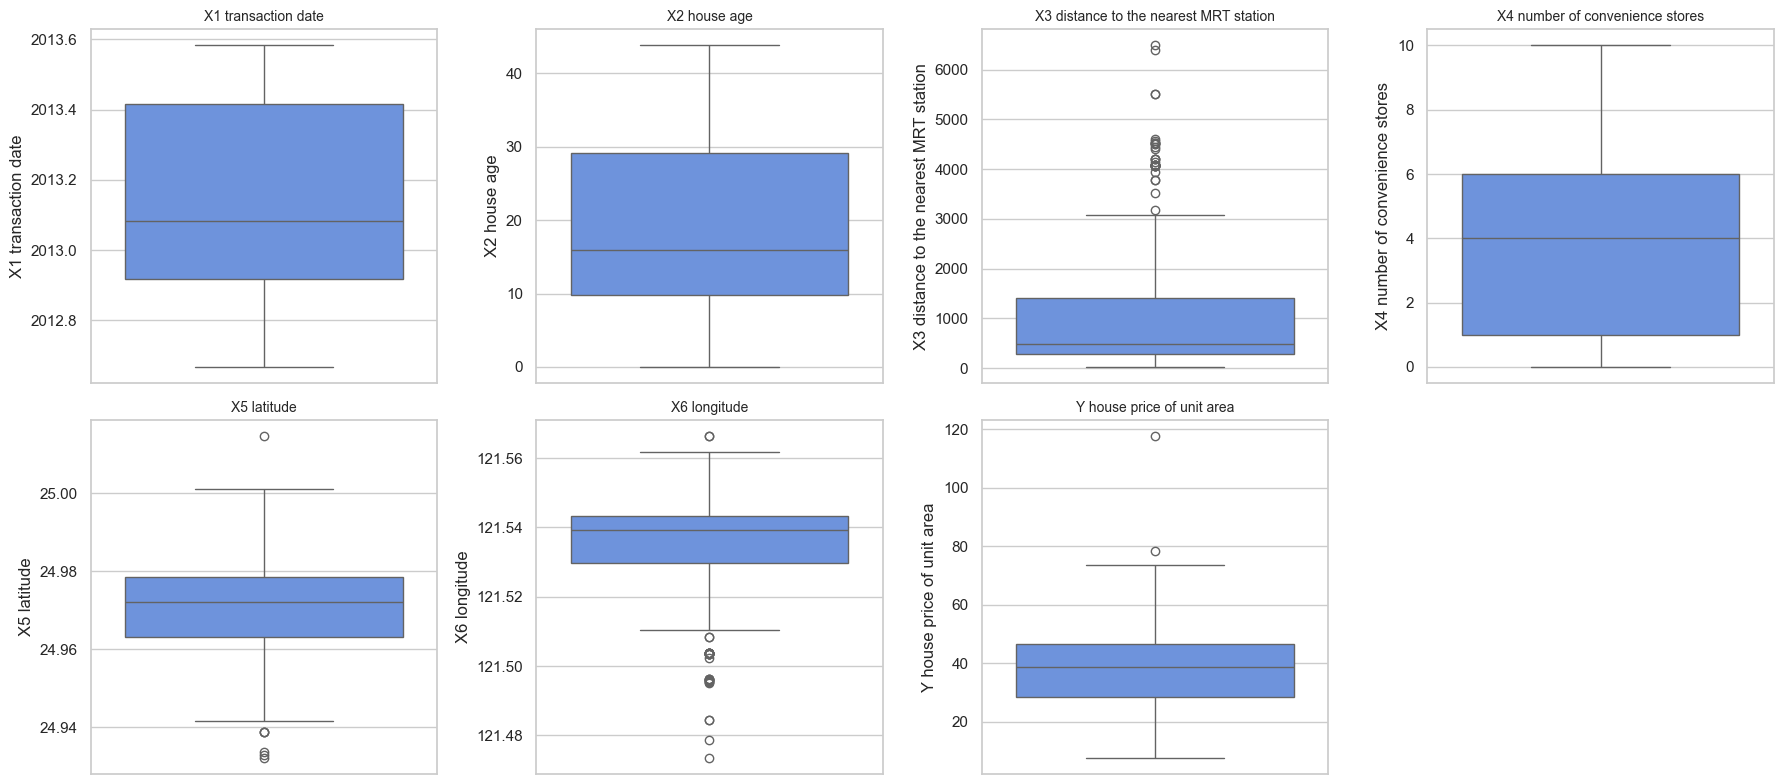

In [5]:
def iqr_outlier_table(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    rows = []
    for column in columns:
        values = df[column].dropna()
        q1, q3 = values.quantile([0.25, 0.75])
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        mask = (values < lower) | (values > upper)
        rows.append(
            {
                "column": column,
                "outliers": int(mask.sum()),
                "outliers_pct": mask.sum() / len(df) * 100,
                "lower_bound": lower,
                "upper_bound": upper,
                "min": values.min(),
                "max": values.max(),
            }
        )
    return pd.DataFrame(rows).sort_values("outliers", ascending=False)


outliers_train = iqr_outlier_table(train, list(train.columns))
outliers_test = iqr_outlier_table(test, list(test.columns))

display(outliers_train)
display(outliers_test)

plot_columns = feature_cols + [TARGET]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()
for ax, column in zip(axes, plot_columns):
    sns.boxplot(y=train[column], ax=ax, color="#5B8DEF")
    ax.set_title(column, fontsize=10)
    ax.set_xlabel("")
for ax in axes[len(plot_columns):]:
    ax.axis("off")
plt.tight_layout()

## 5. Целевая переменная

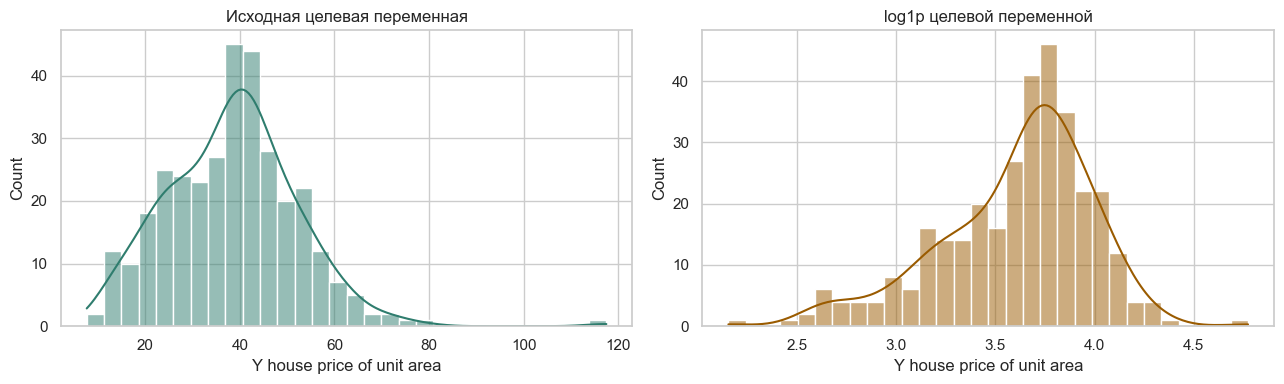

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(train[TARGET], kde=True, bins=30, ax=axes[0], color="#2F7D6E")
sns.histplot(np.log1p(train[TARGET]), kde=True, bins=30, ax=axes[1], color="#9A5B00")
axes[0].set_title("Исходная целевая переменная")
axes[1].set_title("log1p целевой переменной")
plt.tight_layout()

## 6. Связи признаков с ценой

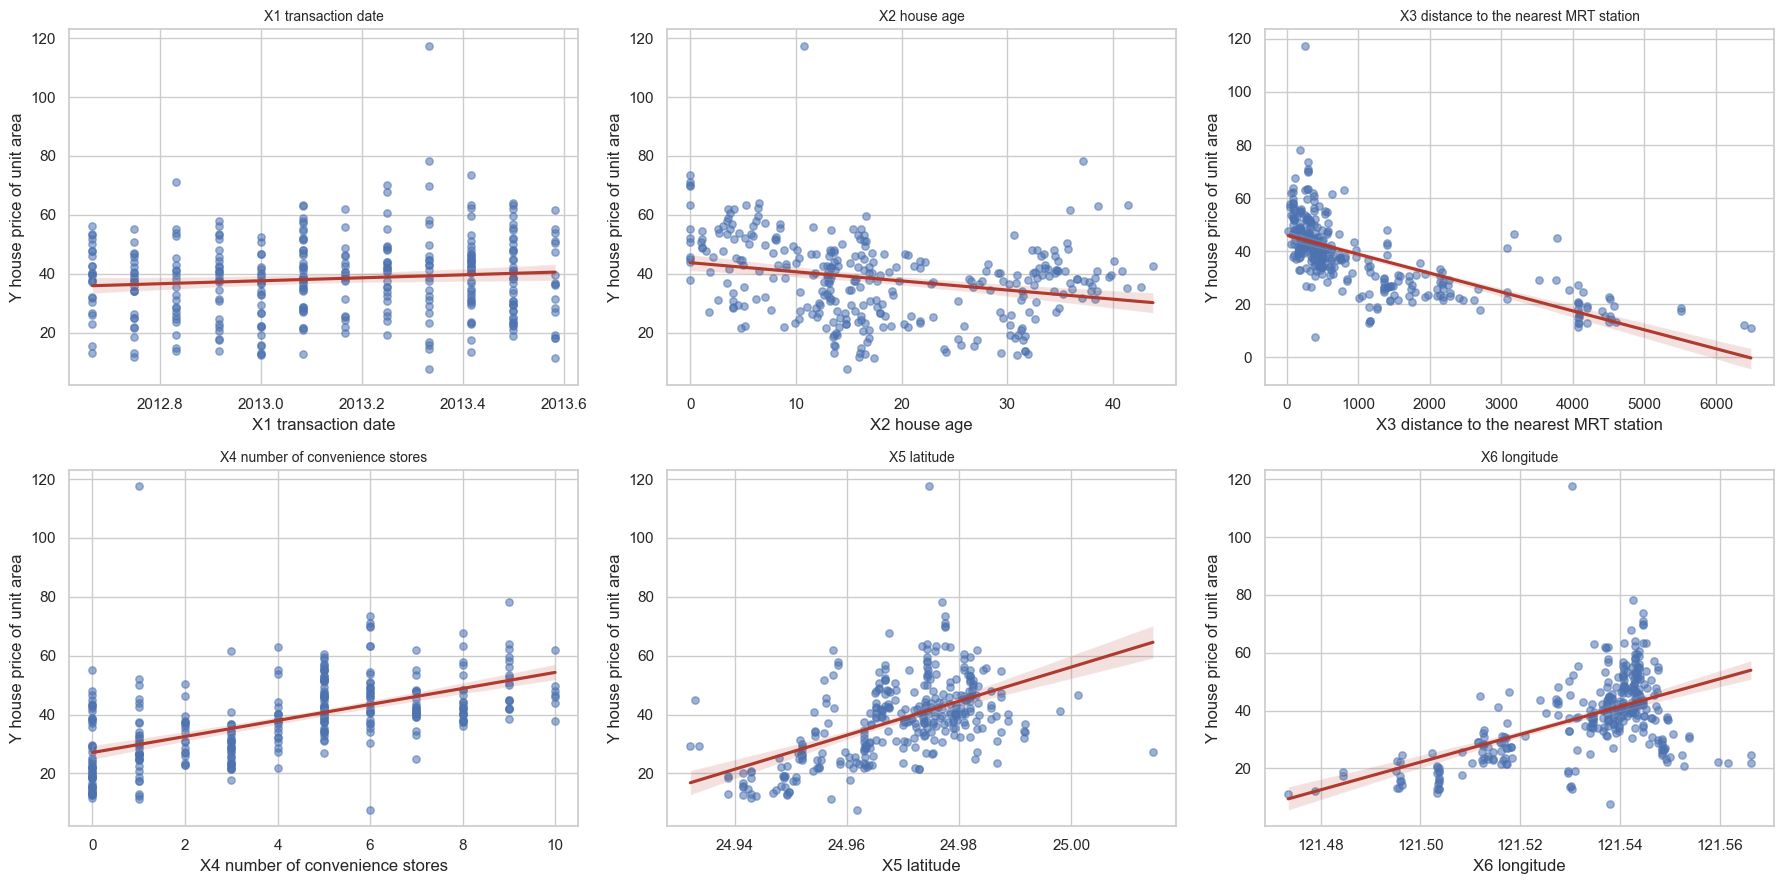

In [7]:
raw_relationships = [
    "X1 transaction date",
    "X2 house age",
    "X3 distance to the nearest MRT station",
    "X4 number of convenience stores",
    "X5 latitude",
    "X6 longitude",
]

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, column in zip(axes.ravel(), raw_relationships):
    data = train[[column, TARGET]].dropna()
    sns.regplot(data=data, x=column, y=TARGET, ax=ax, scatter_kws={"alpha": 0.55, "s": 28}, line_kws={"color": "#B03A2E"})
    ax.set_title(column, fontsize=10)
plt.tight_layout()

## 7. Корреляции признаков

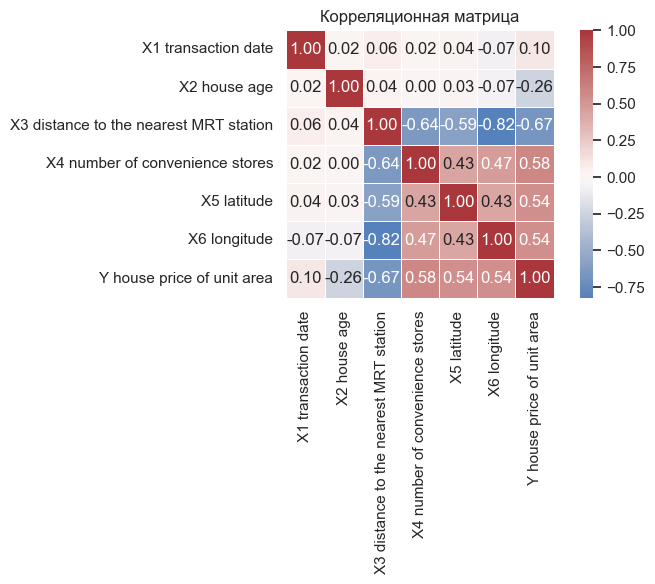

In [8]:
raw_corr = train[feature_cols + [TARGET]].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(raw_corr, annot=True, fmt=".2f", cmap="vlag", center=0, square=True, linewidths=0.5)
plt.title("Корреляционная матрица")
plt.tight_layout()

## 8. Географическая структура

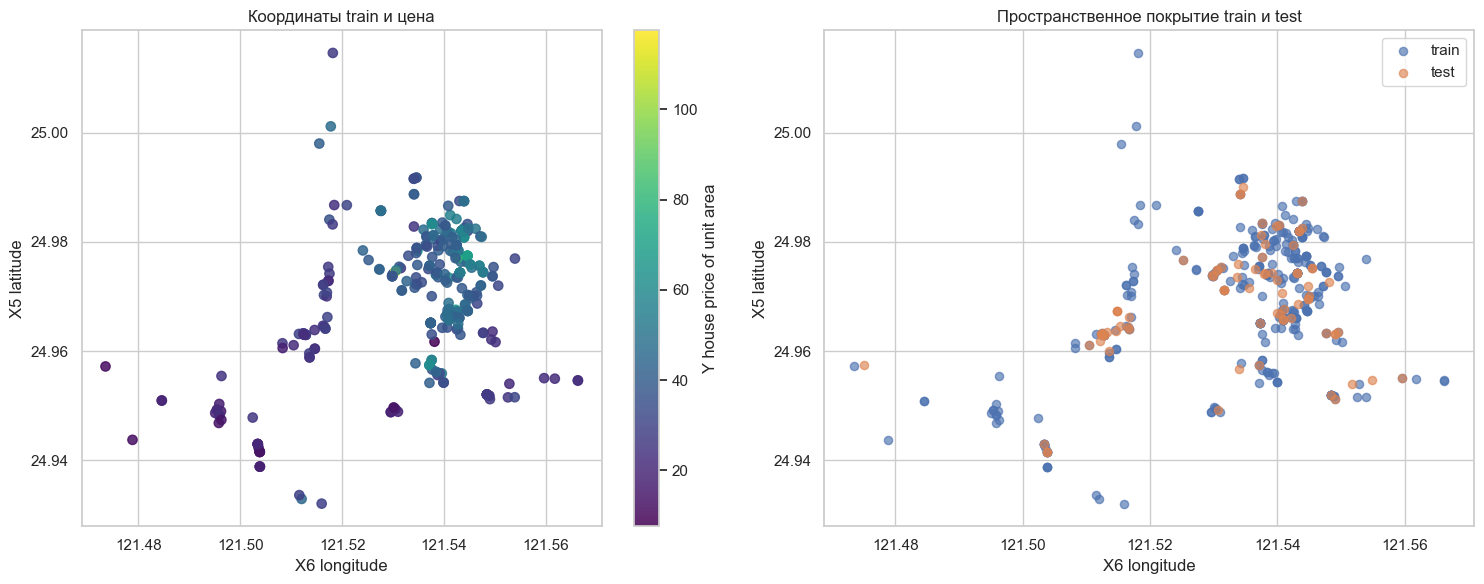

In [9]:
geo_train = train[["X5 latitude", "X6 longitude", TARGET]].dropna()
geo_test = test[["X5 latitude", "X6 longitude"]].dropna()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
points = axes[0].scatter(
    geo_train["X6 longitude"],
    geo_train["X5 latitude"],
    c=geo_train[TARGET],
    cmap="viridis",
    s=45,
    alpha=0.85,
)
axes[0].set_title("Координаты train и цена")
axes[0].set_xlabel("X6 longitude")
axes[0].set_ylabel("X5 latitude")
fig.colorbar(points, ax=axes[0], label=TARGET)

axes[1].scatter(
    geo_train["X6 longitude"],
    geo_train["X5 latitude"],
    s=35,
    alpha=0.65,
    label="train",
)
axes[1].scatter(
    geo_test["X6 longitude"],
    geo_test["X5 latitude"],
    s=35,
    alpha=0.65,
    label="test",
)
axes[1].set_title("Пространственное покрытие train и test")
axes[1].set_xlabel("X6 longitude")
axes[1].set_ylabel("X5 latitude")
axes[1].legend()
plt.tight_layout()

## Вывод

1. Пропуски есть в возрасте дома, расстоянии до MRT и числе магазинов.
2. Описательная статистика показывает различный масштаб признаков, особенно для расстояния до MRT; признаки потребуется масштабировать.
3. Выбросы по IQR наиболее заметны в расстоянии до MRT, координатах и цене.
4. Целевая переменная имеет правый хвост: основная масса объектов находится в среднем ценовом диапазоне, но есть отдельные дорогие наблюдения.
5. Наиболее выраженные визуальные связи с ценой дают расстояние до MRT, число магазинов рядом и координаты объекта.
6. Корреляционная матрица подтверждает ключевую роль расстояния до MRT и географических признаков.
7. Train и test расположены в близком диапазоне координат, тестовая выборка не выглядит как отдельная географическая область.